# Transformer Source Separation (Notebook-Friendly Demo)



This notebook demonstrates a simple encoder-decoder Transformer that separates a mixed 1D time series into two component sources:



- Source A is always a sine wave.

- Source B is one of: square, triangle, sawtooth, or parabolic.



The workflow is split into independent cells:



1. Imports and run configuration

2. Waveform generation helpers

3. Dataset definition

4. Positional encoding + Transformer model

5. Loss and training utilities

6. Visualization utilities

7. Train + evaluate



Run top-to-bottom for a full demonstration.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


@dataclass
class RunConfig:
    # Data
    seq_len: int = 128
    train_n: int = 10_000
    val_n: int = 1_000
    noise: float = 0.02

    # Model
    dim: int = 128
    heads: int = 4
    layers: int = 3
    dropout: float = 0.1

    # Optimization
    epochs: int = 120
    batch_size: int = 64
    lr: float = 3e-4
    grad_clip: float = 1.0
    weight_decay: float = 1e-4


cfg = RunConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
WAVE_KINDS = ("square", "triangle", "sawtooth", "parabolic")


def make_wave(kind: str, freq: float, amp: float, phase: float, t: np.ndarray) -> np.ndarray:
    """Generate one waveform kind evaluated over times t."""
    theta = 2.0 * np.pi * freq * t + phase
    if kind == "sine":
        return (amp * np.sin(theta)).astype(np.float32)
    if kind == "square":
        return (amp * np.sign(np.sin(theta))).astype(np.float32)
    if kind == "triangle":
        p = (theta / (2.0 * np.pi)) % 1.0
        return (amp * (4.0 * np.abs(p - 0.5) - 1.0)).astype(np.float32)
    if kind == "sawtooth":
        p = (theta / (2.0 * np.pi)) % 1.0
        return (amp * (2.0 * p - 1.0)).astype(np.float32)
    if kind == "parabolic":
        s = np.sin(theta)
        return (amp * s * np.abs(s)).astype(np.float32)
    raise ValueError(f"Unknown waveform kind: {kind!r}")

In [3]:
class MixDataset(Dataset):
    """Yields (mix, sources) pairs for source-separation training."""

    def __init__(
        self,
        n: int = 10_000,
        seq_len: int = 128,
        freq_lo: float = 2.0,
        freq_hi: float = 8.0,
        amp_lo: float = 0.6,
        amp_hi: float = 1.4,
        min_freq_gap: float = 1.0,
        noise_std: float = 0.02,
        deterministic: bool = False,
        seed: int = 42,
    ):
        self.n = n
        self.seq_len = seq_len
        self.t = np.linspace(0.0, 1.0, seq_len, dtype=np.float32)
        self.freq_lo = freq_lo
        self.freq_hi = freq_hi
        self.amp_lo = amp_lo
        self.amp_hi = amp_hi
        self.min_freq_gap = min_freq_gap
        self.noise_std = noise_std
        self.deterministic = deterministic
        if deterministic:
            rng = np.random.RandomState(seed)
            self._cache = [self._sample(rng) for _ in range(n)]

    def _sample(self, rng):
        U = rng.uniform
        # Source A: sine wave.
        fa = U(self.freq_lo, self.freq_hi)
        aa = U(self.amp_lo, self.amp_hi)
        pa = U(0.0, 2.0 * np.pi)
        # Source B: one random non-sine waveform.
        kind_b = rng.choice(WAVE_KINDS)
        ab = U(self.amp_lo, self.amp_hi)
        pb = U(0.0, 2.0 * np.pi)
        while True:
            fb = U(self.freq_lo, self.freq_hi)
            if abs(fa - fb) >= self.min_freq_gap:
                break
        sa = make_wave("sine", fa, aa, pa, self.t)
        sb = make_wave(kind_b, fb, ab, pb, self.t)
        mix = sa + sb
        if self.noise_std > 0:
            mix = mix + (rng.randn(len(mix)) * self.noise_std).astype(np.float32)
        return (
            torch.from_numpy(mix).unsqueeze(-1),
            torch.from_numpy(np.stack([sa, sb], axis=-1)),
        )

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        if self.deterministic:
            return self._cache[idx]
        return self._sample(np.random)


mix0, src0 = MixDataset(n=1, seq_len=cfg.seq_len, deterministic=True)[0]
print("mix shape:", tuple(mix0.shape), "| sources shape:", tuple(src0.shape))

mix shape: (128, 1) | sources shape: (128, 2)


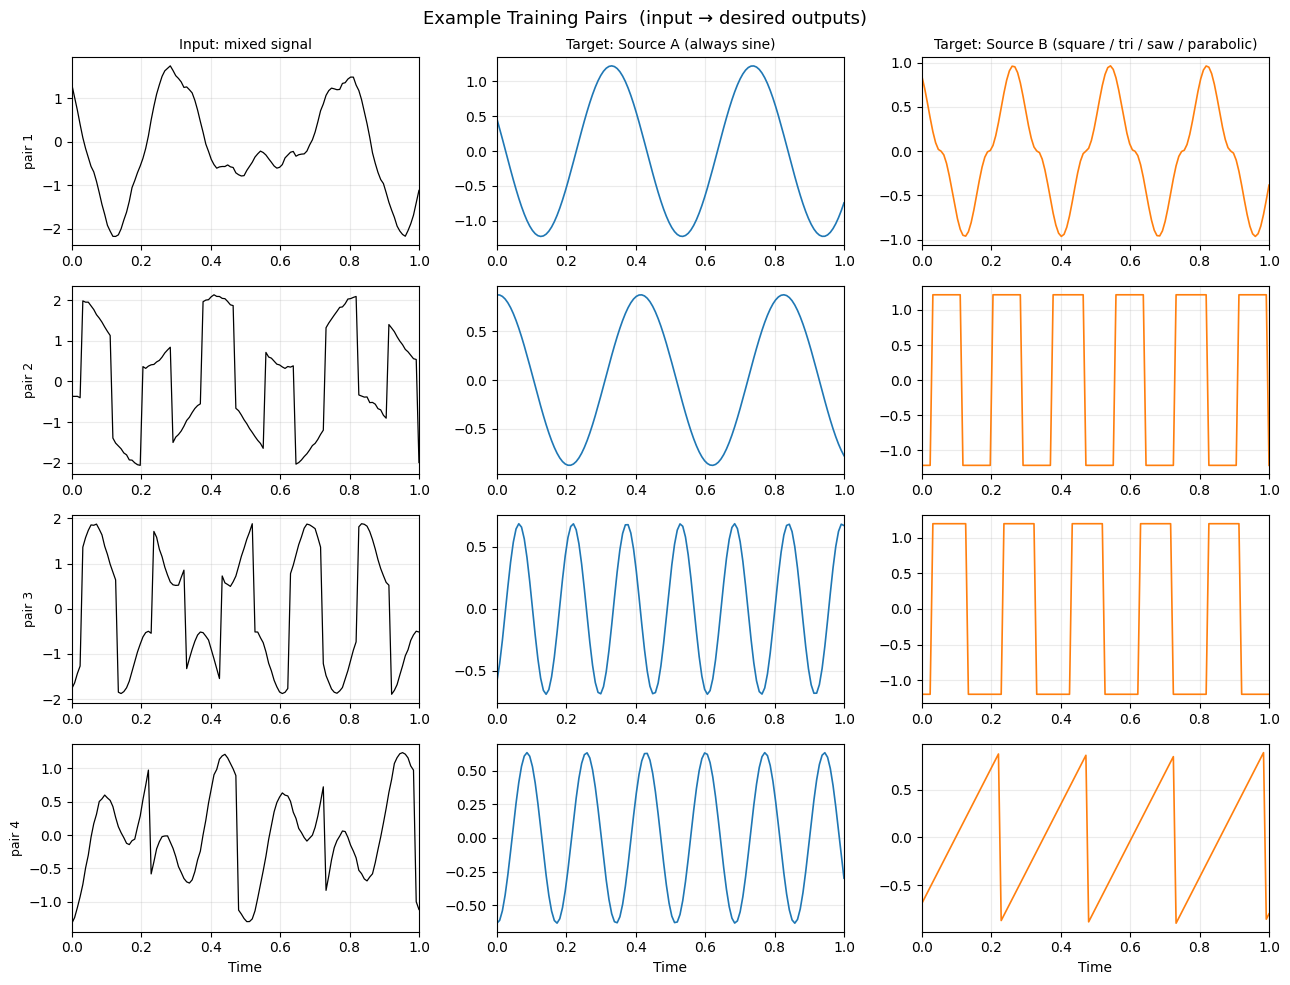

In [4]:
# Example task: what does the model need to learn?
# Left column: the noisy mixed signal fed to the encoder.
# Middle/right columns: the two clean sources the decoder must reconstruct.
ds_preview = MixDataset(n=4, seq_len=cfg.seq_len, noise_std=cfg.noise, deterministic=True, seed=7)
t = np.linspace(0, 1, cfg.seq_len)

fig, axes = plt.subplots(4, 3, figsize=(13, 10), squeeze=False)
fig.suptitle("Example Training Pairs  (input → desired outputs)", fontsize=13)

for i in range(4):
    mix, sources = ds_preview[i]
    mix_np = mix[:, 0].numpy()
    src_np = sources.numpy()

    axes[i][0].plot(t, mix_np, "k", lw=0.9)
    axes[i][0].set_ylabel(f"pair {i + 1}", fontsize=9)
    if i == 0:
        axes[i][0].set_title("Input: mixed signal", fontsize=10)

    axes[i][1].plot(t, src_np[:, 0], "C0", lw=1.2)
    if i == 0:
        axes[i][1].set_title("Target: Source A (always sine)", fontsize=10)

    axes[i][2].plot(t, src_np[:, 1], "C1", lw=1.2)
    if i == 0:
        axes[i][2].set_title("Target: Source B (square / tri / saw / parabolic)", fontsize=10)

for ax in axes.flat:
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.25)
for ax in axes[-1]:
    ax.set_xlabel("Time")

fig.tight_layout()
plt.show()

In [5]:
class SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding."""

    def __init__(self, d: int, max_len: int = 4096):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10_000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]


class Separator(nn.Module):
    """Encoder-decoder Transformer for two-source separation.

    Encoder reads the mixed signal with self-attention to identify frequencies.
    Decoder uses causal self-attention + cross-attention to reconstruct both sources.
    """

    def __init__(
        self,
        d: int = 128,
        heads: int = 4,
        enc_layers: int = 3,
        dec_layers: int = 3,
        dim_ff: int = 256,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.enc_emb = nn.Linear(1, d)   # encoder reads 1-channel mix
        self.dec_emb = nn.Linear(2, d)   # decoder reads 2-channel targets
        self.enc_pe = SinusoidalPE(d, max_len)
        self.dec_pe = SinusoidalPE(d, max_len)

        enc_layer = nn.TransformerEncoderLayer(
            d, heads, dim_ff, dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)

        dec_layer = nn.TransformerDecoderLayer(
            d, heads, dim_ff, dropout, batch_first=True, norm_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, dec_layers)
        self.head = nn.Linear(d, 2)

    @staticmethod
    def _causal_mask(sz: int, device: torch.device) -> torch.Tensor:
        return torch.triu(torch.full((sz, sz), float("-inf"), device=device), diagonal=1)

    @staticmethod
    def shift_right(y: torch.Tensor) -> torch.Tensor:
        """Prepend a zero start-token and drop the last step (teacher forcing)."""
        z = torch.zeros_like(y[:, :1])
        return torch.cat([z, y[:, :-1]], dim=1)

    def encode(self, mix: torch.Tensor) -> torch.Tensor:
        return self.encoder(self.enc_pe(self.enc_emb(mix)))

    def decode(self, tgt: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
        x = self.dec_pe(self.dec_emb(tgt))
        x = self.decoder(x, memory, tgt_mask=self._causal_mask(tgt.size(1), tgt.device))
        return self.head(x)

    def forward(self, mix: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        memory = self.encode(mix)
        dec_input = self.shift_right(targets)
        return self.decode(dec_input, memory)

    @torch.no_grad()
    def generate(self, mix: torch.Tensor) -> torch.Tensor:
        """Autoregressive inference — no teacher forcing."""
        self.eval()
        bsz, seq_len, _ = mix.shape
        memory = self.encode(mix)
        dec_in = torch.zeros(bsz, 1, 2, device=mix.device)
        steps = []
        for _ in range(seq_len):
            pred = self.decode(dec_in, memory)
            step = pred[:, -1:]
            steps.append(step)
            dec_in = torch.cat([dec_in, step], dim=1)
        return torch.cat(steps, dim=1)

In [6]:
def pit_mse(pred: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
    """Permutation-invariant MSE: picks whichever channel assignment gives lower loss."""
    l1 = F.mse_loss(pred, tgt, reduction="none").mean(dim=(1, 2))
    l2 = F.mse_loss(pred.flip(-1), tgt, reduction="none").mean(dim=(1, 2))
    return torch.minimum(l1, l2).mean()


def build_dataloaders(cfg: RunConfig):
    train_dl = DataLoader(
        MixDataset(cfg.train_n, cfg.seq_len, noise_std=cfg.noise),
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_dl = DataLoader(
        MixDataset(cfg.val_n, cfg.seq_len, noise_std=cfg.noise, deterministic=True, seed=123),
        batch_size=cfg.batch_size,
        num_workers=0,
    )
    return train_dl, val_dl


def build_model(cfg: RunConfig, device: torch.device) -> Separator:
    return Separator(
        d=cfg.dim,
        heads=cfg.heads,
        enc_layers=cfg.layers,
        dec_layers=cfg.layers,
        dim_ff=cfg.dim * 2,
        dropout=cfg.dropout,
        max_len=cfg.seq_len + 1,
    ).to(device)


def train_model(
    model: Separator,
    cfg: RunConfig,
    device: torch.device,
    save_path: str = "best_seq2seq.pt",
):
    """Train *model* in-place and return (model, history).

    The model is modified in-place, so you can interrupt training early
    and still use the partially-trained model in subsequent cells.
    """
    train_dl, val_dl = build_dataloaders(cfg)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.epochs)

    best_val = float("inf")
    hist = {"train": [], "val": []}

    for ep in range(1, cfg.epochs + 1):
        model.train()
        train_total = 0.0
        for mix, sources in train_dl:
            mix, sources = mix.to(device), sources.to(device)
            pred = model(mix, sources)
            loss = pit_mse(pred, sources)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            train_total += loss.item() * mix.size(0)

        sched.step()
        train_loss = train_total / cfg.train_n
        hist["train"].append(train_loss)

        model.eval()
        val_total = 0.0
        with torch.no_grad():
            for mix, sources in val_dl:
                mix, sources = mix.to(device), sources.to(device)
                val_total += pit_mse(model(mix, sources), sources).item() * mix.size(0)
        val_loss = val_total / cfg.val_n
        hist["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)

        if ep == 1 or ep % 10 == 0:
            lr_now = sched.get_last_lr()[0]
            print(
                f"epoch {ep:4d}/{cfg.epochs}  "
                f"train {train_loss:.6f}  val {val_loss:.6f}  "
                f"best {best_val:.6f}  lr {lr_now:.1e}"
            )

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, hist

In [7]:
def align_channels(pred: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
    """Resolve the channel-permutation ambiguity left by PIT loss."""
    if F.mse_loss(pred, tgt).item() <= F.mse_loss(pred.flip(-1), tgt).item():
        return pred
    return pred.flip(-1)


def plot_curves(hist: dict):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(hist["train"], label="train", alpha=0.8)
    ax.plot(hist["val"], label="val", alpha=0.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_yscale("log")
    ax.legend()
    ax.set_title("Training Progress")
    fig.tight_layout()
    plt.show()


def plot_examples(model: Separator, cfg: RunConfig, device: torch.device, n: int = 4, ar: bool = False):
    """Plot separation results: mixed input, source A, source B."""
    ds = MixDataset(n, cfg.seq_len, noise_std=cfg.noise, deterministic=True, seed=999)
    tag = "autoregressive" if ar else "teacher-forced"

    fig, axes = plt.subplots(n, 3, figsize=(13, 2.6 * n), squeeze=False)
    model.eval()
    t = np.linspace(0, 1, cfg.seq_len)

    for i in range(n):
        mix, sources = ds[i]
        mix_d = mix.unsqueeze(0).to(device)
        src_d = sources.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model.generate(mix_d) if ar else model(mix_d, src_d)
        pred = align_channels(pred, src_d)[0].cpu().numpy()
        mix_np = mix[:, 0].numpy()
        src_np = sources.numpy()

        axes[i][0].plot(t, mix_np, "k", lw=0.8)
        axes[i][0].set_ylabel(f"ex {i + 1}", fontsize=9)
        if i == 0:
            axes[i][0].set_title("Mixed Input", fontsize=10)

        for ch, title in enumerate(["Source A (sine)", "Source B (other)"]):
            ax = axes[i][ch + 1]
            ax.plot(t, src_np[:, ch], "C0", lw=1.3, alpha=0.7, label="truth")
            ax.plot(t, pred[:, ch], "C1", lw=1.3, alpha=0.7, ls="--", label="pred")
            if i == 0:
                ax.set_title(title, fontsize=10)
                ax.legend(fontsize=7, loc="upper right")

    for ax in axes.flat:
        ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.25)
    for ax in axes[-1]:
        ax.set_xlabel("Time")

    fig.suptitle(f"Source Separation — {tag}", fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()

In [8]:
# Optional: speed settings for quick iteration.
# Set QUICK_RUN = False to use the full training configuration from RunConfig above.
QUICK_RUN = True
if QUICK_RUN:
    cfg.epochs = 30
    cfg.train_n = 3_000
    cfg.val_n = 600

print(cfg)

RunConfig(seq_len=128, train_n=3000, val_n=600, noise=0.02, dim=128, heads=4, layers=3, dropout=0.1, epochs=30, batch_size=64, lr=0.0003, grad_clip=1.0, weight_decay=0.0001)


In [9]:
# Build the untrained model.
# After this cell runs, `model` is a valid (random-weight) Separator you can
# inspect, profile, or pass to the training cell below.
model = build_model(cfg, device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready — {n_params:,} trainable parameters")

Model ready — 994,690 trainable parameters


/var/folders/gf/4tjws8ss2s38tgx7_7csppcm0000gq/T/ipykernel_79399/2511974294.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)


In [13]:
# Train the model.
# You can interrupt this cell early — `model` is modified in-place, so the
# cells below will still work with whatever training has been completed.
model, hist = train_model(model, cfg, device)

epoch    1/30  train 0.079232  val 0.058887  best 0.058887  lr 3.0e-04
epoch   10/30  train 0.042211  val 0.033444  best 0.033444  lr 2.3e-04
epoch   20/30  train 0.023319  val 0.014429  best 0.014364  lr 7.5e-05
epoch   30/30  train 0.020161  val 0.010831  best 0.010827  lr 0.0e+00


Teacher-forced predictions (decoder sees ground truth at each step):


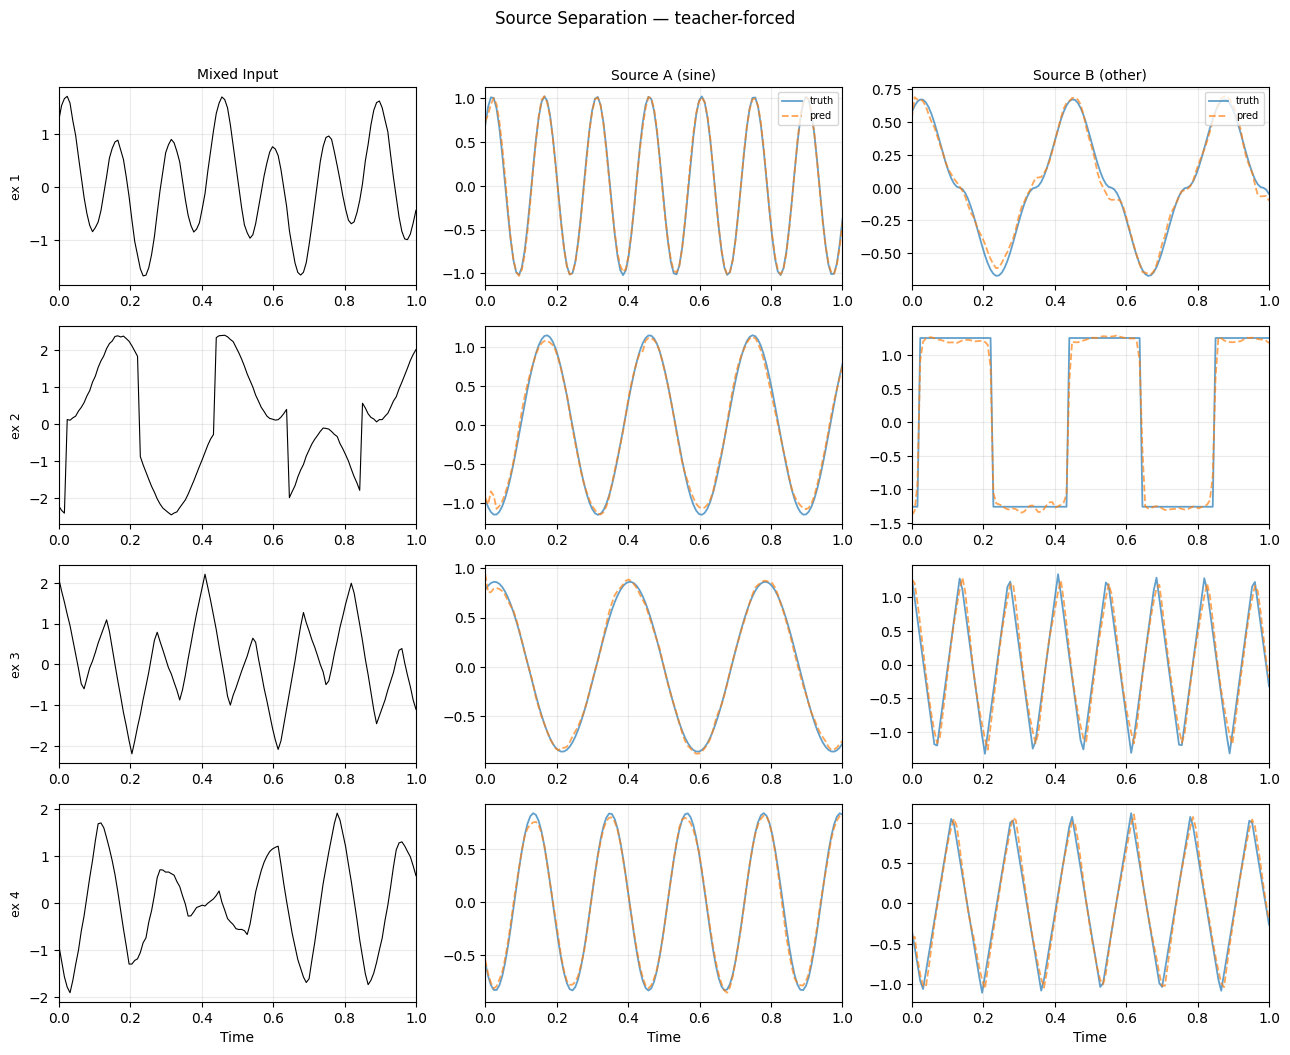

Autoregressive predictions (decoder feeds its own output back):


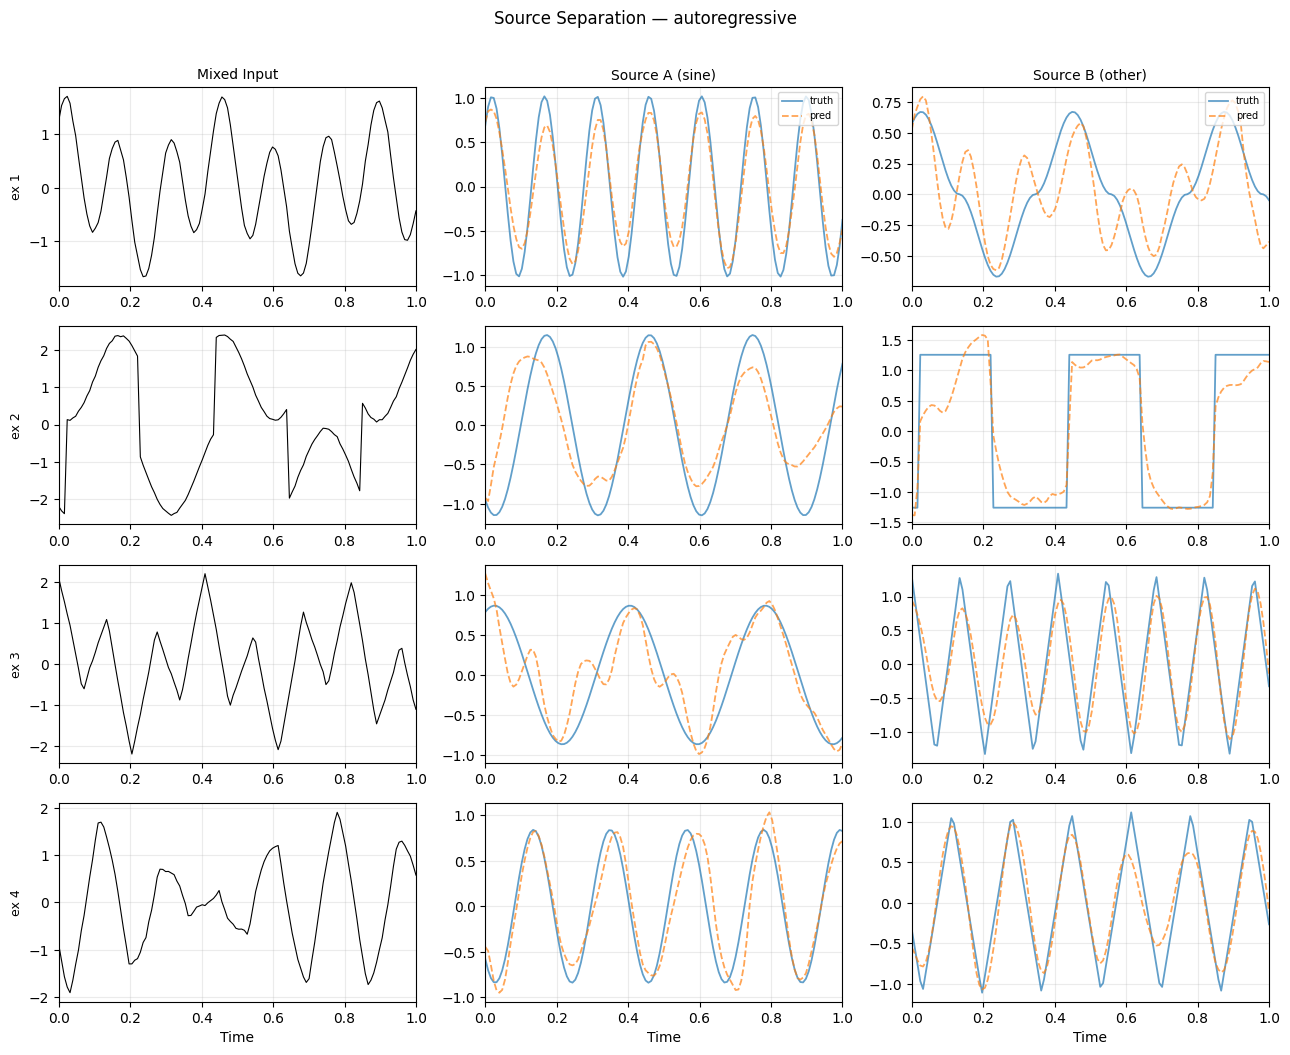

In [14]:
# Evaluate and visualize results.
#plot_curves(hist)

print("Teacher-forced predictions (decoder sees ground truth at each step):")
plot_examples(model, cfg, device, ar=False)

print("Autoregressive predictions (decoder feeds its own output back):")
plot_examples(model, cfg, device, ar=True)